In [ ]:
pip install qiskit qiskit-aer pylatexenc

  Using cached qiskit-2.4.1-cp310-abi3-manylinux_2_28_x86_64.whl.metadata (12 kB)
  Using cached qiskit_aer-0.17.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (8.3 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 61.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 84.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 85.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.6 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=5d67f3ec51961f555fef6b89972102a9af224be504e216478a088c0305c38910
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


# Data Encoding in Quantum Computing

In quantum machine learning and quantum data processing, **encoding** means:

$$
\text{How do we convert classical data into a quantum state?}
$$

Three common methods are:

1. Basis Encoding
2. Amplitude Encoding
3. Angle Encoding (Rotation Encoding)

---

# 1. Basis Encoding

Basis encoding stores classical binary values directly into qubit basis states.

$$
|0\rangle =
\begin{bmatrix}
1\\
0
\end{bmatrix}
\quad
|1\rangle =
\begin{bmatrix}
0\\
1
\end{bmatrix}
$$

For multiple qubits:

$$
|0101\rangle
$$

means:

$$
|0\rangle \otimes |1\rangle \otimes |0\rangle \otimes |1\rangle
$$

## Example

Suppose:

$$
x = [1,0,1]
$$

Using basis encoding:

$$
x \rightarrow |101\rangle
$$

We need 3 qubits.

The state vector becomes:

$$
|101\rangle =
\begin{bmatrix}
0\\
0\\
0\\
0\\
0\\
1\\
0\\
0
\end{bmatrix}
$$

because $|101\rangle$ corresponds to decimal 5.

## Circuit Preparation

Start from:

$$
|000\rangle
$$

Apply X gates where bit = 1.

- First bit = 1 → apply X on qubit 0
- Second bit = 0 → no operation
- Third bit = 1 → apply X on qubit 2

Result:

$$
|101\rangle
$$

## Advantages

- Simple
- Easy to implement

## Disadvantages

- Requires many qubits
- Cannot naturally represent continuous values

---


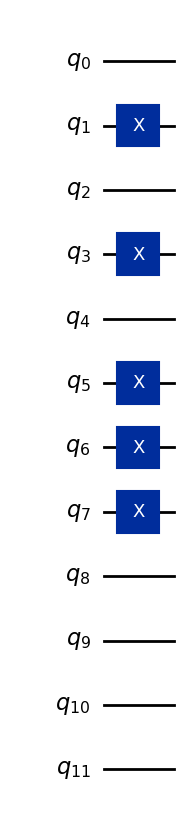

In [ ]:
from qiskit import QuantumCircuit

x_bits = [int(b) for b in format(5, "04b")]
y_bits = [int(b) for b in format(7, "04b")]
z_bits = [int(b) for b in format(0, "04b")]

all_bits = x_bits + y_bits + z_bits

qc = QuantumCircuit(12)

for indx, bit in enumerate(all_bits):
  if bit == 1:
    qc.x(indx)

qc.draw('mpl')


# 2. Amplitude Encoding

Amplitude encoding stores data inside probability amplitudes.

General quantum state:

$$
|\psi\rangle =
\sum_{i=0}^{2^n-1} \alpha_i |i\rangle
$$

where:

$$
\sum_i |\alpha_i|^2 = 1
$$

## Example

Suppose:

$$
x = [1,2,3,4]
$$

### Step 1: Normalize

$$
||x|| =
\sqrt{1^2+2^2+3^2+4^2}
=
\sqrt{30}
$$

Normalized vector:

$$
\left[
\frac1{\sqrt{30}},
\frac2{\sqrt{30}},
\frac3{\sqrt{30}},
\frac4{\sqrt{30}}
\right]
$$

### Step 2: Create Quantum State

Since:

$$
4 = 2^2
$$

we need 2 qubits.

The state becomes:

$$
|\psi\rangle
=
\frac1{\sqrt{30}}|00\rangle
+
\frac2{\sqrt{30}}|01\rangle
+
\frac3{\sqrt{30}}|10\rangle
+
\frac4{\sqrt{30}}|11\rangle
$$

## Advantages

- Very memory efficient
- Powerful for quantum machine learning

## Disadvantages

- State preparation is difficult
- Loading data may require complex circuits

---



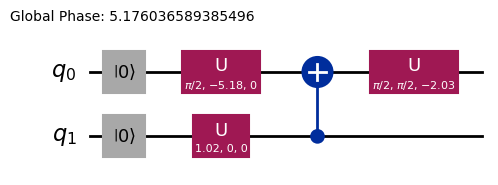

In [ ]:
import math

states = [1 / math.sqrt(105) * 4,
          1 / math.sqrt(105) * 8,
          1 / math.sqrt(105) * 5,
          1 / math.sqrt(105) * 0,
          ]

qc = QuantumCircuit(2)
qc.initialize(states, [0, 1])

qc.decompose().decompose().decompose().decompose().decompose().draw('mpl')

In [ ]:
from qiskit.quantum_info import Statevector

sv = Statevector.from_instruction(qc)

print(sv)

Statevector([0.39036003+0.j, 0.78072006+0.j, 0.48795004+0.j,
             0.        +0.j],
            dims=(2, 2))



# 3. Angle Encoding

Angle encoding stores classical values as rotation angles.

Common gates:

$$
R_x(\theta),\quad
R_y(\theta),\quad
R_z(\theta)
$$

## Rotation Gate

$$
R_y(\theta)=
\begin{bmatrix}
\cos(\theta/2) & -\sin(\theta/2)\\
\sin(\theta/2) & \cos(\theta/2)
\end{bmatrix}
$$

Applied to $|0\rangle$:

$$
R_y(\theta)|0\rangle
=
\cos(\theta/2)|0\rangle
+
\sin(\theta/2)|1\rangle
$$

## Example

Suppose:

$$
x = [0.2,\ 1.0,\ 2.4]
$$

Apply:

$$
R_y(0.2)
$$

$$
R_y(1.0)
$$

$$
R_y(2.4)
$$

to three qubits.

## Single-Qubit Example

If:

$$
\theta = \frac{\pi}{2}
$$

then:

$$
R_y\left(\frac{\pi}{2}\right)|0\rangle
=
\cos\left(\frac{\pi}{4}\right)|0\rangle
+
\sin\left(\frac{\pi}{4}\right)|1\rangle
$$

Since:

$$
\cos(\pi/4)=\sin(\pi/4)=\frac1{\sqrt2}
$$

the state becomes:

$$
\frac1{\sqrt2}|0\rangle
+
\frac1{\sqrt2}|1\rangle
$$

which is a superposition state.

## Advantages

- Easy to implement
- Good for variational quantum circuits

## Disadvantages

- Usually requires one qubit per feature
- No exponential compression

---

# Comparison Table

| Encoding | Idea | Qubits Needed | Strength |
|---|---|---|---|
| Basis Encoding | Store bits directly | n bits → n qubits | Simple |
| Amplitude Encoding | Store data in amplitudes | $2^n$ values in n qubits | Exponential compression |
| Angle Encoding | Store data as rotation angles | Usually 1 feature per qubit | Easy for QML |

---


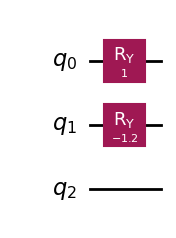

In [ ]:

from math import pi

qc = QuantumCircuit(3)
qc.ry(1,0)
qc.ry(-1.2,1)
qc.draw('mpl')



# Phase Encoding in Quantum Computing

Phase encoding stores classical information inside the **phase** of a quantum state.

Unlike:

- Basis Encoding → stores data in basis states
- Amplitude Encoding → stores data in amplitudes
- Angle Encoding → stores data in rotation amplitudes

Phase encoding stores information in:

$$
e^{i\phi}
$$

where:

- \(i = \sqrt{-1}\)
- \(\phi\) is the phase angle

---

# 1. Complex Numbers in Quantum Computing

Quantum amplitudes can be complex numbers.

General qubit state:

$$
|\psi\rangle
=
\alpha|0\rangle
+
\beta|1\rangle
$$

where:

$$
\alpha,\beta \in \mathbb{C}
$$

Example:

$$
|\psi\rangle
=
\frac1{\sqrt2}|0\rangle
+
\frac{i}{\sqrt2}|1\rangle
$$

Notice:

- first amplitude is real
- second amplitude has phase \(i\)

---

# 2. What is Phase?

A phase is a complex rotation.

Euler’s formula:

$$
e^{i\phi}
=
\cos(\phi)+i\sin(\phi)
$$

This creates a rotation in the complex plane.

---

# 3. General Phase-Encoded State

A quantum state with phase:

$$
|\psi\rangle
=
\frac1{\sqrt2}|0\rangle
+
\frac{e^{i\phi}}{\sqrt2}|1\rangle
$$

Here:

- amplitudes have same magnitude
- but different phase

---

# Important Observation

Measurement probabilities are:

$$
\left|\frac1{\sqrt2}\right|^2
=
\frac12
$$

and

$$
\left|\frac{e^{i\phi}}{\sqrt2}\right|^2
=
\frac12
$$

because:

$$
|e^{i\phi}|=1
$$

So phase does NOT directly change probabilities.

Instead:

# Phase affects interference.

This is extremely important.

---

# 4. Example of Phase Encoding

Suppose classical value:

$$
x = 1.2
$$

Encode it as phase:

$$
\phi = 1.2
$$

Quantum state becomes:

$$
|\psi\rangle
=
\frac1{\sqrt2}|0\rangle
+
\frac{e^{i1.2}}{\sqrt2}|1\rangle
$$

The data is now stored in the phase.

---

# 5. Phase Gates

Common phase gates:

| Gate | Matrix |
|---|---|
| Z Gate | \( \begin{bmatrix}1&0\\0&-1\end{bmatrix} \) |
| S Gate | \( \begin{bmatrix}1&0\\0&i\end{bmatrix} \) |
| T Gate | \( \begin{bmatrix}1&0\\0&e^{i\pi/4}\end{bmatrix} \) |

General phase gate:

$$
P(\phi)=
\begin{bmatrix}
1 & 0\\
0 & e^{i\phi}
\end{bmatrix}
$$

---

# 6. How Phase Encoding Works

Start with superposition:

$$
|+\rangle
=
\frac1{\sqrt2}(|0\rangle+|1\rangle)
$$

Apply phase gate:

$$
P(\phi)
$$

Result:

$$
|\psi\rangle
=
\frac1{\sqrt2}
\left(
|0\rangle
+
e^{i\phi}|1\rangle
\right)
$$

Now the information is encoded into the phase difference.

---

# 7. Why Phase Matters

Phase controls interference.

Quantum algorithms work by:

- amplifying correct answers
- canceling wrong answers

using phase interference.

---

# Example

Two amplitudes:

$$
1 + (-1) = 0
$$

This is destructive interference.

Another example:

$$
1 + 1 = 2
$$

Constructive interference.

Phases determine whether amplitudes:

- add
- cancel
- rotate

---

# 8. Phase Encoding in Quantum Algorithms

Phase encoding is used heavily in:

- Quantum Fourier Transform (QFT)
- Phase Estimation
- Shor’s Algorithm
- Grover’s Algorithm
- Quantum Signal Processing
- Variational Quantum Circuits

---

# What Happens Here?

## Step 1

Hadamard gate:

$$
|0\rangle
\rightarrow
\frac1{\sqrt2}(|0\rangle+|1\rangle)
$$

## Step 2

Phase gate:

$$
|1\rangle
\rightarrow
e^{i\phi}|1\rangle
$$

Final state:

$$
|\psi\rangle
=
\frac1{\sqrt2}
\left(
|0\rangle
+
e^{i\phi}|1\rangle
\right)
$$

---

# 10. Important Insight

Amplitude encoding stores information in:

$$
|\alpha_i|
$$

Phase encoding stores information in:

$$
e^{i\phi}
$$

So:

- amplitude = size/magnitude
- phase = angle/rotation in complex plane

---

# 11. Bloch Sphere Interpretation

On Bloch sphere:

- amplitude changes latitude
- phase changes longitude

Phase rotates the state around the Z-axis.

---

# 12. Comparison Table

| Encoding | Stores Information In |
|---|---|
| Basis Encoding | Basis states |
| Amplitude Encoding | Amplitude magnitudes |
| Angle Encoding | Rotation angles |
| Phase Encoding | Complex phases |

---

# 13. Deep Intuition

Phase encoding does not usually affect direct measurement probabilities.

Instead:

it changes how amplitudes interfere later in computation.

This is why phase is one of the most powerful concepts in quantum algorithms.

Quantum computing is fundamentally:

$$
\text{controlled manipulation of amplitudes and phases}
$$

In [ ]:
from qiskit.quantum_info import Statevector
from math import pi

qc = QuantumCircuit(1)
qc.h(0)
state1 = Statevector.from_instruction(qc)
print(state1)



Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))


In [ ]:
qc.p(pi / 2, 0)
state2 = Statevector.from_instruction(qc)
print(state2)

Statevector([7.07106781e-01+0.j        , 4.32978028e-17+0.70710678j],
            dims=(2,))


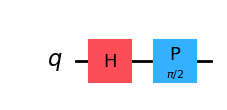

In [ ]:
states = state1, state2
qc.draw("mpl", scale=1)

# Dense Angle Encoding (DAE)

Dense Angle Encoding (DAE) is a quantum data encoding technique that combines:

- Angle Encoding
- Phase Encoding

to store multiple classical features into fewer qubits.

---

# 1. Main Idea

A single qubit state has two continuous parameters:

$$
|\psi\rangle
=
\cos\left(\frac{\theta}{2}\right)|0\rangle
+
e^{i\phi}
\sin\left(\frac{\theta}{2}\right)|1\rangle
$$

where:

- \(\theta\) controls amplitudes
- \(\phi\) controls phase

Dense Angle Encoding uses BOTH parameters to encode data.

---

# 2. Why It Is Called “Dense”

Normal angle encoding:

$$
1 \text{ feature} \rightarrow 1 \text{ qubit}
$$

Dense angle encoding:

$$
2 \text{ features} \rightarrow 1 \text{ qubit}
$$

This doubles the information density.

---

# 3. Single-Qubit Dense Encoding Formula

Suppose two classical features:

$$
x_1,\ x_2
$$

The dense encoded qubit becomes:

$$
|\psi\rangle
=
\cos\left(\frac{x_1}{2}\right)|0\rangle
+
e^{ix_2}
\sin\left(\frac{x_1}{2}\right)|1\rangle
$$

---

# 4. Meaning of Each Feature

| Feature | Stored In |
|---|---|
| \(x_1\) | Amplitude / Rotation |
| \(x_2\) | Phase |

---

# 5. How Encoding Is Performed

Dense angle encoding usually uses:

$$
R_y(x_1)
$$

and

$$
R_z(x_2)
$$

on the same qubit.

---

# 6. Rotation Interpretation

## Step 1: Amplitude Encoding

Apply:

$$
R_y(x_1)
$$

This changes the amplitudes:

$$
\alpha,\beta
$$

and therefore changes measurement probabilities.

---

## Step 2: Phase Encoding

Apply:

$$
R_z(x_2)
$$

This changes the relative phase:

$$
e^{ix_2}
$$

without directly changing probabilities.

---

# 7. Multi-Qubit Dense Encoding

Suppose dataset:

$$
(x_1,x_2,x_3,x_4)
$$

Dense angle encoding groups them into pairs:

| Qubit | Encoded Features |
|---|---|
| q0 | \(x_1,x_2\) |
| q1 | \(x_3,x_4\) |

Total state becomes:

$$
|\vec{x}\rangle
=
\bigotimes_{k=1}^{N/2}
\left(
\cos\left(\frac{x_{2k-1}}{2}\right)|0\rangle
+
e^{ix_{2k}}
\sin\left(\frac{x_{2k-1}}{2}\right)|1\rangle
\right)
$$

---

# 8. Understanding the Formula

The symbol:

$$
\bigotimes
$$

means tensor product.

It combines multiple qubit states into one quantum system.

---

# 9. Example

Suppose:

$$
x_1 = \frac{3\pi}{8}
$$

$$
x_2 = \frac{7\pi}{4}
$$

Encoded state:

$$
|\psi\rangle
=
\cos\left(\frac{3\pi}{16}\right)|0\rangle
+
e^{i7\pi/4}
\sin\left(\frac{3\pi}{16}\right)|1\rangle
$$


---

# 11. Bloch Sphere Interpretation

A qubit on the Bloch sphere is described by:

- Polar angle (\(\theta\))
- Azimuth angle (\(\phi\))

Dense angle encoding uses both coordinates.

| Bloch Sphere Parameter | Encoded Feature |
|---|---|
| \(\theta\) | Feature 1 |
| \(\phi\) | Feature 2 |

---

# 12. Comparison With Normal Angle Encoding

| Encoding Type | Features per Qubit |
|---|---|
| Normal Angle Encoding | 1 |
| Dense Angle Encoding | 2 |

---

# 13. Advantages

- Requires fewer qubits
- Better qubit utilization
- Useful for NISQ devices
- Combines amplitude and phase information

---

# 14. Limitations

- Information extraction is difficult
- Measurements remain probabilistic
- Circuit optimization becomes harder
- Noise affects phase information strongly

---

# 15. Important Insight

Dense Angle Encoding combines:

- rotation-based encoding
- phase-based encoding

into a single qubit.

Instead of using only amplitudes, it fully utilizes the qubit state:

$$
|\psi\rangle
=
\cos\left(\frac{\theta}{2}\right)|0\rangle
+
e^{i\phi}
\sin\left(\frac{\theta}{2}\right)|1\rangle
$$

to pack more classical information into quantum systems.

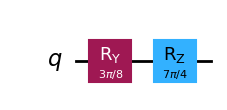

In [ ]:
qc = QuantumCircuit(1)
state1 = Statevector.from_instruction(qc)
qc.ry(3 * pi / 8, 0)

state2 = Statevector.from_instruction(qc)
qc.rz(7 * pi / 4, 0)

state3 = Statevector.from_instruction(qc)
states = state1, state2, state3

qc.draw('mpl')